### Notebook for exploration of the dataset locally generated

In [1]:
import duckdb
import pandas as pd 
import matplotlib.pyplot as plt

Download the new parquet generated from queries_pvdaq.py

In [2]:
df = pd.read_parquet("../data/pvdaq_system10_2019_2023.parquet")

Check dataset for missing values and statistical description

In [3]:
print(df.isna().sum())
print(df.describe())

timestamp               0
irradiance          87442
dc_power             3839
ac_power             4537
ambient_temp         4986
module_temp_mean    10021
dtype: int64
                        timestamp    irradiance      dc_power      ac_power  \
count                     1990900  1.903458e+06  1.987061e+06  1.986363e+06   
mean   2021-03-22 14:03:10.291617  2.424826e+02  2.241957e+02  1.819323e+02   
min           2019-01-03 07:52:00  0.000000e+00  0.000000e+00  0.000000e+00   
25%           2020-04-18 06:04:45  0.000000e+00  0.000000e+00  0.000000e+00   
50%           2021-04-02 20:01:30  2.601300e+00  6.043000e-02  0.000000e+00   
75%           2022-03-15 13:36:15  3.909375e+02  3.592300e+02  2.914600e+02   
max           2023-03-01 06:59:00  4.938000e+03  1.638500e+03  1.339500e+03   
std                           NaN  3.813654e+02  3.507303e+02  2.873634e+02   

       ambient_temp  module_temp_mean  
count  1.985914e+06      1.980879e+06  
mean   1.194464e+01      1.767829e+01  

In [4]:
monthly = (
    df.set_index("timestamp")["irradiance"]
    .resample("ME")
    .agg(["count", "size"])
)

monthly["missing_pct"] = (
    1 - monthly["count"] / monthly["size"]
) * 100

monthly[["missing_pct"]]

,missing_pct
timestamp,
2019-01-31,76.742627
2019-02-28,59.488491
2019-03-31,4.819866
2019-04-30,0.000000
2019-05-31,0.000000
2019-06-30,0.000000
2019-07-31,0.000000
2019-08-31,0.000000
2019-09-30,0.000000


is NaN values or non-registered data? 

In [5]:
missing_irradiance = df[df["irradiance"].isna()]

print(missing_irradiance["timestamp"].min())
print(missing_irradiance["timestamp"].max())

2019-01-03 07:52:00
2022-07-25 15:22:00


In [6]:
missing_by_month = (
    missing_irradiance
    .set_index("timestamp")
    .resample("ME")
    .size()
)

print(missing_by_month)

timestamp
2019-01-31     1145
2019-02-28     1163
2019-03-31      887
2019-04-30        0
2019-05-31        0
2019-06-30        0
2019-07-31        0
2019-08-31        0
2019-09-30        0
2019-10-31        0
2019-11-30        0
2019-12-31        0
2020-01-31        0
2020-02-29        0
2020-03-31        0
2020-04-30        0
2020-05-31        0
2020-06-30        0
2020-07-31        0
2020-08-31        0
2020-09-30        0
2020-10-31        0
2020-11-30        0
2020-12-31        0
2021-01-31        0
2021-02-28        5
2021-03-31        0
2021-04-30        0
2021-05-31        0
2021-06-30        0
2021-07-31        0
2021-08-31        0
2021-09-30        0
2021-10-31        0
2021-11-30        0
2021-12-31        0
2022-01-31        0
2022-02-28        0
2022-03-31        0
2022-04-30        2
2022-05-31    13771
2022-06-30    41702
2022-07-31    28767
Freq: ME, dtype: int64


the 2022 period of missing values looks like there was a problem with the sensor of irradiance, let's check it and also for 2019, just in case

In [7]:
bad_period_2022 = df[
    df["timestamp"].between("2022-05-01", "2022-07-25")
]

print(bad_period_2022.isna().sum())

timestamp               0
irradiance          84233
dc_power                0
ac_power                0
ambient_temp            0
module_temp_mean        0
dtype: int64


In [8]:
bad_period_2019 = df[
    df["timestamp"].between("2019-01-03", "2019-03-31")
]

print(bad_period_2019.isna().sum())

timestamp              0
irradiance          3195
dc_power            3832
ac_power            4529
ambient_temp        4975
module_temp_mean    4896
dtype: int64


once we are sure about the periods of missing values, we are going to drop them, because irradiance will be a very important feature and this will confuse our model

In [9]:
# Eliminar periodo defectuoso de 2019
df = df[
    ~df["timestamp"].between("2019-01-03", "2019-03-31")
]

# Eliminar periodo defectuoso de 2022
df = df[
    ~df["timestamp"].between("2022-05-01", "2022-07-25")
]

we saw anomalies for irradiance, let's check it with a boxplot to see outliers

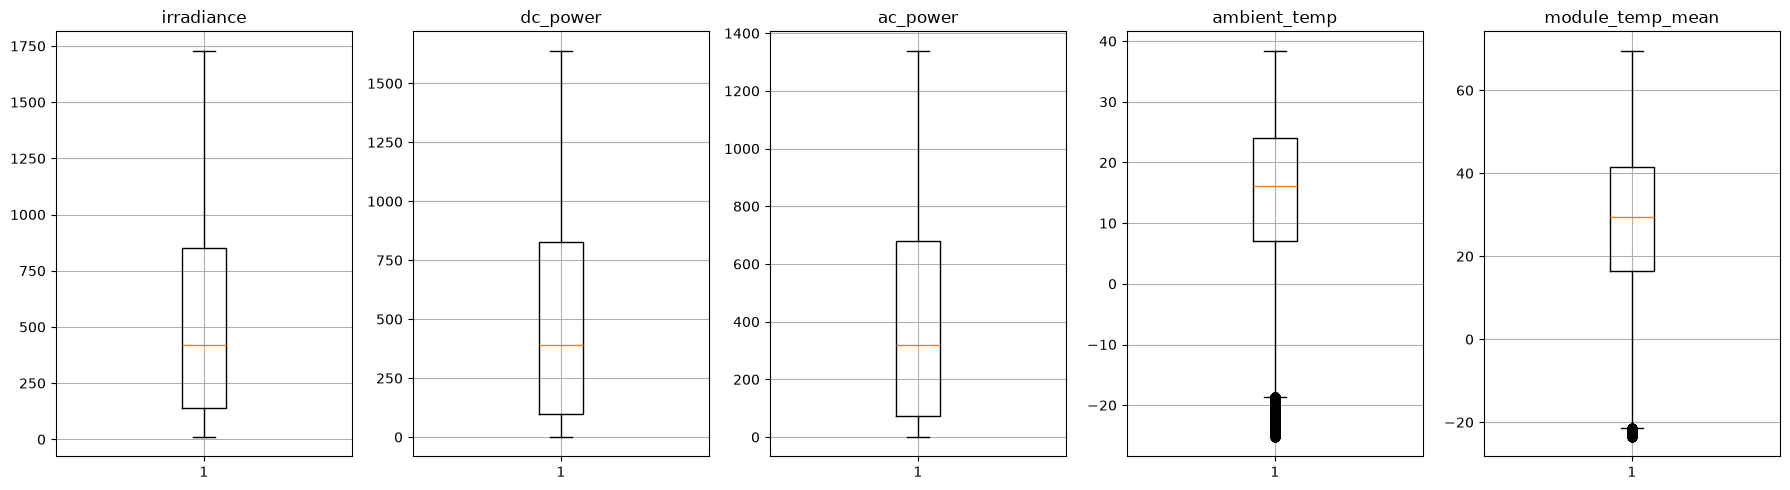

,timestamp,irradiance,dc_power,ac_power,ambient_temp,module_temp_mean
count,888265,888265.000000,888262.000000,888261.000000,888263.000000,886364.000000
mean,2021-02-06 13:20:01.990081,493.809728,466.965484,379.701002,15.120455,28.738084
min,2019-03-31 00:01:00,10.001000,0.000000,0.000000,-25.251000,-23.580333
25%,2020-03-22 17:18:00,137.960000,96.713000,72.340000,6.992300,16.373583
50%,2021-02-10 20:56:00,417.420000,390.930000,318.740000,16.147000,29.541333
75%,2021-12-17 22:55:00,850.620000,828.600000,680.080000,24.057500,41.536083
max,2023-03-01 00:30:00,1729.200000,1638.500000,1339.500000,38.430000,69.542000
std,NaN,376.950502,381.645179,314.832224,11.113010,16.932310


In [10]:
df_plot = df[df["irradiance"] > 10]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

variables = [
    "irradiance",
    "dc_power",
    "ac_power",
    "ambient_temp",
    "module_temp_mean"
]

for ax, variable in zip(axes, variables):
    ax.boxplot(df_plot[variable].dropna())
    ax.set_title(variable)
    ax.grid(True)

plt.tight_layout()
plt.show()
df_plot.describe()

df.loc[df["irradiance"] > 1500, ["timestamp", "irradiance"]].head()
df.loc[df["irradiance"] > 1500, "timestamp"].agg(["min", "max"])

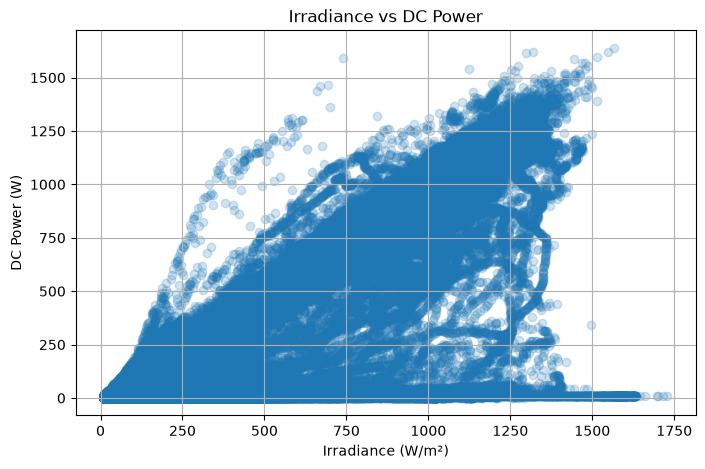

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_plot["irradiance"],
    df_plot["dc_power"],
    alpha=0.2
)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("DC Power (W)")
plt.title("Irradiance vs DC Power")
plt.grid(True)
plt.show()

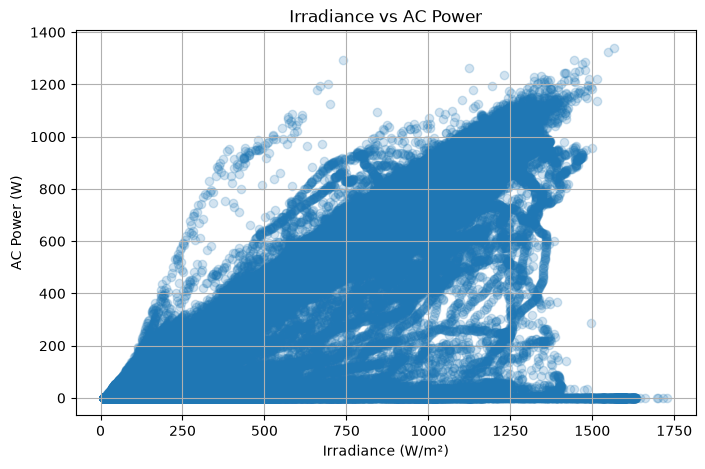

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_plot["irradiance"],
    df_plot["ac_power"],
    alpha=0.2
)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("AC Power (W)")
plt.title("Irradiance vs AC Power")
plt.grid(True)
plt.show()

the ratio between dc/ac power should be always dc>ac, let's check if this is true and if not let's see if is only noise or maybe invalid data

In [13]:
print(df.loc[
    df["dc_power"] < df["ac_power"],
    ["timestamp", "irradiance", "dc_power", "ac_power", "ambient_temp", "module_temp_mean"]
].head(20))

                 timestamp  irradiance  dc_power  ac_power  ambient_temp  \
99361  2019-05-24 20:01:00    1052.900    0.0000   0.01107      21.37600   
368336 2019-11-27 14:56:00     327.890   15.9130  19.57000     -10.90300   
368826 2019-11-27 23:06:00      45.398    3.0977   3.46050      -9.47490   
368827 2019-11-27 23:07:00      43.628    1.6918   2.19610      -9.52350   
368828 2019-11-27 23:08:00      40.974    1.3531   1.86330      -9.54480   
369735 2019-11-28 14:15:00      74.871    7.7507   8.14740     -10.58000   
371222 2019-11-29 15:02:00      59.088    9.1312   9.72200      -9.40060   
371256 2019-11-29 15:36:00      95.328   19.5280  19.67700      -8.21290   
399467 2020-02-03 18:47:00      76.463    3.7694   3.99400      -7.82290   
399499 2020-02-03 19:19:00     121.130    5.0162   5.18110      -7.65170   
420850 2020-02-18 15:10:00     210.300   10.9850  12.39700      -6.44460   
431480 2020-02-26 00:20:00      30.525    2.5054   2.60710      -5.87760   
464181 2020-

let's study the data whit high irradiance and low power production

In [14]:
low_power_high_irr = df[
    (df["irradiance"] > 500) &
    (df["ac_power"] < 50)
]

print(len(low_power_high_irr))

5724


In [16]:
low_power_high_irr['year_month'] = (
    low_power_high_irr['timestamp']
    .dt.to_period('M')
)

print(
    low_power_high_irr['year_month']
    .value_counts()
    .sort_index()
)

year_month
2019-05      13
2019-06       1
2019-07      29
2019-10     317
2019-11       9
2020-02     466
2020-04      70
2020-06      11
2020-10     306
2020-11      13
2020-12      27
2021-01      43
2021-02     166
2021-04      31
2021-05      27
2021-06     291
2021-07      12
2021-09      17
2021-10       5
2021-12      39
2022-01     112
2022-02     606
2022-03     130
2022-04      19
2022-08       6
2022-09     295
2022-10       1
2022-11    1695
2022-12     416
2023-01      48
2023-02     503
Freq: M, Name: count, dtype: int64


let's check periods with big amount of days of high irradiance and low power

In [17]:
nov_2022 = low_power_high_irr[
    low_power_high_irr["year_month"] == "2022-11"
]

print(nov_2022["timestamp"].min())
print(nov_2022["timestamp"].max())

2022-11-04 14:40:00
2022-11-29 18:49:00


In [18]:
nov_2022['timestamp'].dt.date.value_counts().sort_index()

timestamp
2022-11-04     31
2022-11-15     27
2022-11-18     37
2022-11-24    118
2022-11-25    491
2022-11-26    471
2022-11-27    430
2022-11-28     77
2022-11-29     13
Name: count, dtype: int64

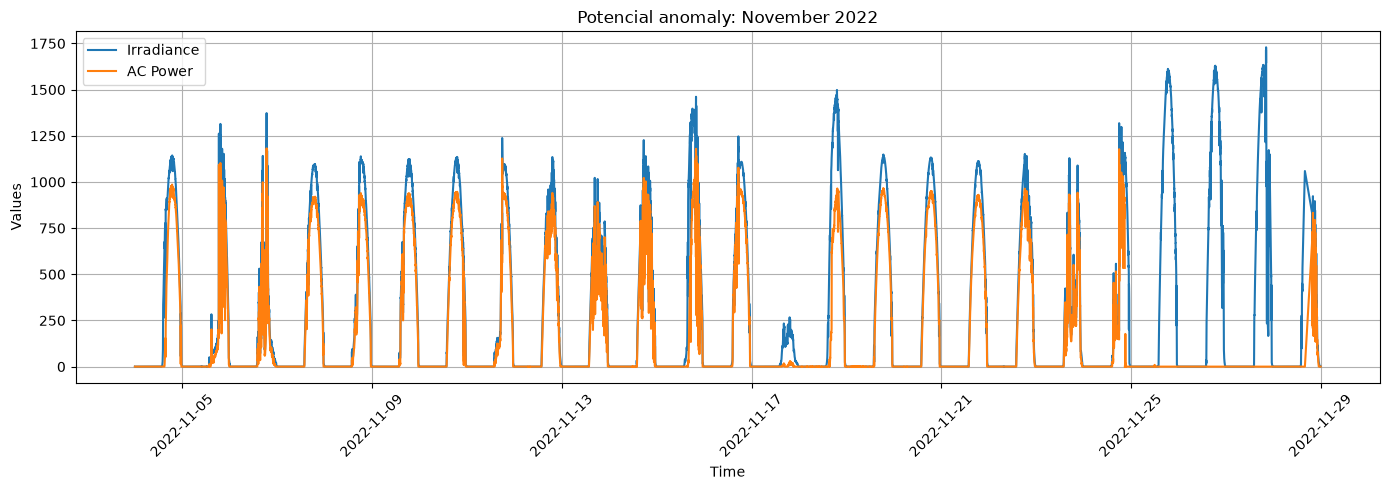

In [20]:
nov_problem = df[
    df['timestamp'].between(
        '2022-11-04',
        '2022-11-29'
    )
]

plt.figure(figsize=(14, 5))
plt.plot(nov_problem['timestamp'], nov_problem['irradiance'], label='Irradiance')
plt.plot(nov_problem['timestamp'], nov_problem['ac_power'], label='AC Power')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Potencial anomaly: November 2022')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

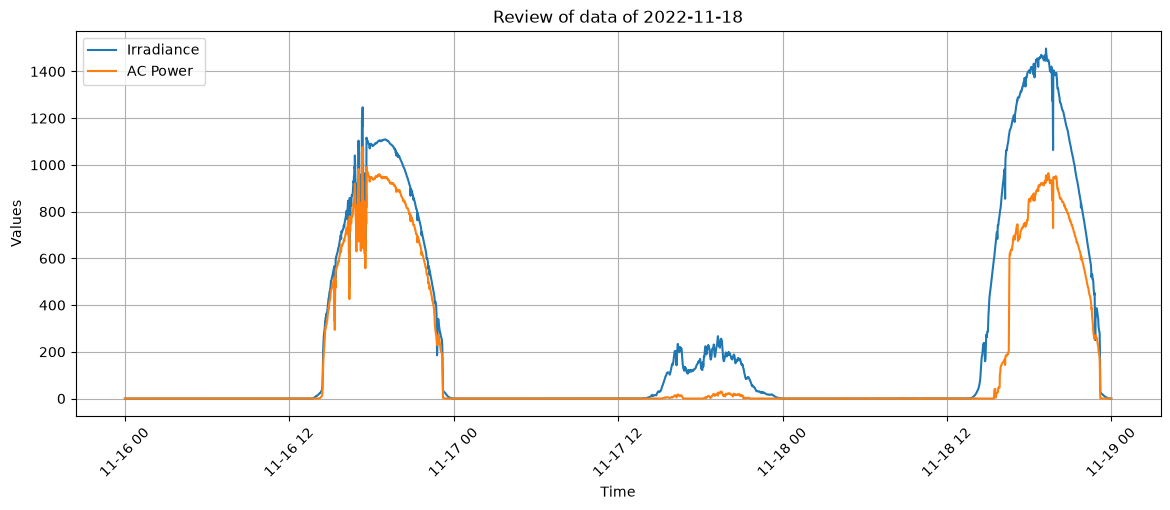

In [22]:
nov_problem_18 = df[
    df['timestamp'].between(
        '2022-11-16',
        '2022-11-19'
    )
]

plt.figure(figsize=(14, 5))
plt.plot(nov_problem_18['timestamp'], nov_problem_18['irradiance'], label='Irradiance')
plt.plot(nov_problem_18['timestamp'], nov_problem_18['ac_power'], label='AC Power')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Review of data of 2022-11-18')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

It seems that values from 18 of november of 2022 are excesively low due to a very bad metereological situation, we cannot confirm without checking external data, but the values of ac power following the figure of irradiance give us an idea, so we are going to leave those day in the dataset

now let's find points where there was high irradiance and low ac power grouping by date

In [25]:
low_power_high_irr = df[
    (df["irradiance"] > 500) &
    (df["ac_power"] < 50)
].copy()

low_power_high_irr["date"] = low_power_high_irr["timestamp"].dt.date

daily_anomalies = (
    low_power_high_irr
    .groupby("date")
    .agg(
        anomalous_points=("ac_power", "size"),
        max_irradiance=("irradiance", "max"),
        min_ac_power=("ac_power", "min"),
        mean_ac_power=("ac_power", "mean")
    )
    .sort_values("anomalous_points", ascending=False)
)

daily_anomalies.head(20)

,anomalous_points,max_irradiance,min_ac_power,mean_ac_power
date,,,,
2022-11-25,491,1612.30,0.0000,0.000000
2022-11-26,471,1629.50,0.0000,0.000000
2022-11-27,430,1729.20,0.0000,0.000000
2023-02-23,359,1351.40,0.0000,20.636683
2022-02-23,339,1366.80,0.0000,27.467275
2022-12-22,326,1239.70,2.2667,24.926129
2020-02-05,255,1406.30,0.0000,9.845642
2021-06-11,239,1025.90,0.0000,0.057123
2022-09-23,215,1173.00,0.0000,0.024604


and being more precisely, seeing which is the rate of low power taking into acount the total number of points registered along the day

In [27]:
high_irr = df[df['irradiance'] > 500].copy()
high_irr['date'] = high_irr['timestamp'].dt.date

daily = (
    high_irr
    .groupby('date')
    .agg(
        total_points=('ac_power', 'size'),
        low_power_points=('ac_power', lambda x: (x<50).sum())
    )
)

daily['low_power_pct'] = (
    daily['low_power_points']/daily['total_points']*100
)

daily.sort_values('low_power_pct', ascending=False).head(20)

,total_points,low_power_points,low_power_pct
date,,,
2022-09-22,21,21,100.000000
2020-10-26,211,211,100.000000
2022-11-27,430,430,100.000000
2022-11-26,471,471,100.000000
2022-11-25,491,491,100.000000
2020-04-13,14,14,100.000000
2019-10-10,4,4,100.000000
2022-01-01,100,100,100.000000
2023-02-22,26,26,100.000000


let's group candidates of a shutdown of the station to identify real anomalous values

In [31]:
daily_shutdown_candidates = daily.join(
    daily_anomalies["mean_ac_power"]
) # join is for keeping the columns of mean_ac_power  in the new dataframe

daily_shutdown_candidates = daily_shutdown_candidates[
    (daily_shutdown_candidates["total_points"] >= 200) &
    (daily_shutdown_candidates["low_power_pct"] >= 80) &
    (daily_shutdown_candidates["mean_ac_power"] <= 5)
]

print(daily_shutdown_candidates)

            total_points  low_power_points  low_power_pct  mean_ac_power
date                                                                    
2020-10-26           211               211          100.0       0.503244
2022-11-25           491               491          100.0       0.000000
2022-11-26           471               471          100.0       0.000000
2022-11-27           430               430          100.0       0.000000


In [35]:
df["date"] = df["timestamp"].dt.date

shutdown_dates = daily_shutdown_candidates.index

df["plant_status"] = "normal"

df.loc[
    df["date"].isin(shutdown_dates),
    "plant_status"
] = "shutdown_candidate"

df.loc[
    (~df["date"].isin(shutdown_dates)) &
    (df["irradiance"] > 500) &
    (df["ac_power"] < 50),
    "plant_status"
] = "unexplained_anomaly"


In [36]:
df[['ambient_temp', 'module_temp_mean']].isna().sum()

ambient_temp          11
module_temp_mean    5125
dtype: int64

In [37]:
df.loc[
    df['ambient_temp'].isna(),
    ['timestamp', 'ambient_temp']
]

,timestamp,ambient_temp
649117,2020-08-04 10:40:00,NaN
649152,2020-08-04 11:40:00,NaN
650783,2020-08-05 15:41:00,NaN
651832,2020-08-06 11:40:00,NaN
654361,2020-08-08 07:35:00,NaN
655750,2020-08-09 07:40:00,NaN
657198,2020-08-10 09:40:00,NaN
658849,2020-08-11 13:36:00,NaN
675384,2020-08-23 07:35:00,NaN
678654,2020-08-25 15:36:00,NaN


In [40]:
df["ambient_temp"] = df["ambient_temp"].interpolate()

In [41]:
df["ambient_temp"].isna().sum()

np.int64(0)

In [38]:
df.loc[
    df["module_temp_mean"].isna(),
    ["timestamp", "module_temp_mean"]
].head(20)

,timestamp,module_temp_mean
649117,2020-08-04 10:40:00,NaN
649152,2020-08-04 11:40:00,NaN
650783,2020-08-05 15:41:00,NaN
651612,2020-08-06 07:40:00,NaN
651832,2020-08-06 11:40:00,NaN
654361,2020-08-08 07:35:00,NaN
655750,2020-08-09 07:40:00,NaN
657103,2020-08-10 07:40:00,NaN
657198,2020-08-10 09:40:00,NaN
658849,2020-08-11 13:36:00,NaN


In [43]:
is_nan = df["module_temp_mean"].isna()

groups = is_nan.ne(is_nan.shift()).cumsum()

nan_blocks = (
    is_nan[is_nan]
    .groupby(groups)
    .size()
    .sort_values(ascending=False)
)

print(nan_blocks.head(20))

module_temp_mean
96     1455
104    1183
98     1146
100     469
106     281
30      175
92      130
34      104
102      79
94       31
90       10
74        5
38        5
70        4
86        3
28        3
68        2
56        2
44        2
72        2
Name: module_temp_mean, dtype: int64


In [46]:
is_nan = df["module_temp_mean"].isna()

groups = is_nan.ne(is_nan.shift()).cumsum()

nan_blocks = (
    df[is_nan]
    .assign(group=groups[is_nan])
    .groupby("group")
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        n_missing=("timestamp", "size")
    )
)

nan_blocks["duration"] = (
    nan_blocks["end"] - nan_blocks["start"]
)

nan_blocks.sort_values(
    "n_missing",
    ascending=False
).head(20)


,start,end,n_missing,duration
group,,,,
96,2022-11-25 10:59:00,2022-11-26 11:13:00,1455,1 days 00:14:00
104,2022-11-27 15:36:00,2022-11-28 11:18:00,1183,0 days 19:42:00
98,2022-11-26 11:16:00,2022-11-27 06:21:00,1146,0 days 19:05:00
100,2022-11-27 06:24:00,2022-11-27 14:12:00,469,0 days 07:48:00
106,2022-11-28 11:20:00,2022-11-28 16:00:00,281,0 days 04:40:00
30,2022-11-24 21:40:00,2022-11-25 00:34:00,175,0 days 02:54:00
92,2022-11-25 08:12:00,2022-11-25 10:21:00,130,0 days 02:09:00
34,2022-11-25 00:47:00,2022-11-25 02:30:00,104,0 days 01:43:00
102,2022-11-27 14:14:00,2022-11-27 15:32:00,79,0 days 01:18:00
